## Code to look at publicly available nc files

In [3]:
import xarray as xr
fn0 = 's3://liveocean-test/his_nc_files/ocean_his_0001.nc'
storage_options = {'client_kwargs': {'endpoint_url': 'https://s3.kopah.uw.edu'}, 'anon': True}
ds = xr.open_dataset(fn0, engine='h5netcdf', storage_options=storage_options)

#### First look at a single file

In [4]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:          (tracer: 14, boundary: 4, s_rho: 30, s_w: 31,
                      eta_rho: 1302, xi_rho: 663, eta_u: 1302, xi_u: 662,
                      eta_v: 1301, xi_v: 663, eta_psi: 1301, xi_psi: 662,
                      ocean_time: 1)
Coordinates:
  * s_rho            (s_rho) float64 240B -0.9833 -0.95 ... -0.05 -0.01667
  * s_w              (s_w) float64 248B -1.0 -0.9667 -0.9333 ... -0.03333 0.0
    lon_rho          (eta_rho, xi_rho) float64 7MB ...
    lat_rho          (eta_rho, xi_rho) float64 7MB ...
    lon_u            (eta_u, xi_u) float64 7MB ...
    lat_u            (eta_u, xi_u) float64 7MB ...
    lon_v            (eta_v, xi_v) float64 7MB ...
    lat_v            (eta_v, xi_v) float64 7MB ...
    lon_psi          (eta_psi, xi_psi) float64 7MB ...
    lat_psi          (eta_psi, xi_psi) float64 7MB ...
  * ocean_time       (ocean_time) datetime64[ns] 8B 2026-05-18
Dimensions without coordinates: tracer, boundary, eta_rho, xi_rho, eta_u, xi_u,
                                eta_v, xi_v, eta_psi, xi_psi
Data variables: (12/163)
    ntimes           int32 4B ...
    ndtfast          int32 4B ...
    dt               float64 8B ...
    dtfast           float64 8B ...
    dstart           datetime64[ns] 8B ...
    shuffle          int32 4B ...
    ...               ...
    EminusP          (ocean_time, eta_rho, xi_rho) float32 3MB ...
    swrad            (ocean_time, eta_rho, xi_rho) float32 3MB ...
    sustr            (ocean_time, eta_u, xi_u) float32 3MB ...
    svstr            (ocean_time, eta_v, xi_v) float32 3MB ...
    bustr            (ocean_time, eta_u, xi_u) float32 3MB ...
    bvstr            (ocean_time, eta_v, xi_v) float32 3MB ...
Attributes: (12/43)
    file:              /gscratch/macc/parker/LO_roms/cas7_t2_x11b/f2026.05.18...
    format:            netCDF-4/HDF5 file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS history file
    title:             LiveOcean input file
    var_info:          /gscratch/macc/parker/LO_roms_source_git/ROMS/External...
    ...                ...
    compiler_flags:    -fp-model precise -heap-arrays -ip -O3 -traceback -che...
    tiling:            12x16
    history:           ROMS, Version 4.3, Monday - May 18, 2026 -  3:20:13 AM
    ana_file:          ROMS/Functionals/ana_btflux.h, ROMS/Functionals/ana_st...
    CPP_options:       X11B, ADD_FSOBC, ADD_M2OBC, ANA_BPFLUX, ANA_BSFLUX, AN...
    bio_file:          /gscratch/macc/parker/LO_roms_user/x11b/fennel.h

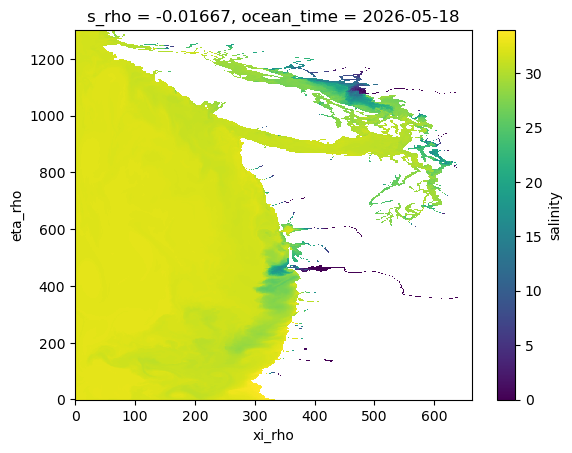

In [5]:
ds.salt[0,-1,:,:].plot()

#### Next make a time series from all the files

In [21]:
fn00 = 's3://liveocean-test/his_nc_files/ocean_his_'
fn_list = []
for hh in range (1,26):
    hn = ('000' + str(hh))[-4:]
    fn_list.append(fn00 + hn + '.nc')
# fn_list

#### I had to do the set_options and data_vars things below to avoid some warning messages

I wonder if it is faster when using limited data_vars?

In [18]:
xr.set_options(use_new_combine_kwarg_defaults=True)

In [19]:
ds1 = xr.open_mfdataset(fn_list, engine='h5netcdf', storage_options=storage_options, data_vars=['zeta'])

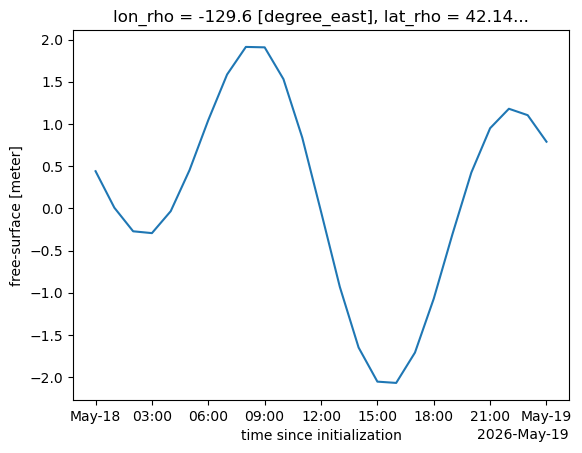

In [20]:
ds1.zeta[:,10,10].plot()